In [1]:
# CRITICAL: RUN THIS CELL FIRST if you see 'ModuleNotFoundError'
# This installs the required libraries into your current Jupyter kernel
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn numpy nbformat


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Ecommerce Dataset Visualization & Feature Engineering
Created for analysis of `diversified_ecommerce_dataset.csv`.

## 1. Setup and Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configure visual settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load dataset
df = pd.read_csv("diversified_ecommerce_dataset.csv")
df.head()

,Product ID,Product Name,Category,Price,Discount,Tax Rate,Stock Level,Supplier ID,Customer Age Group,Customer Location,Customer Gender,Shipping Cost,Shipping Method,Return Rate,Seasonality,Popularity Index
0,P6879,Jacket,Apparel,53.85,5,15,150,S535,35-44,"New York, USA",Male,23.32,Standard,4.49,No,56
1,P5132,Camera,Electronics,761.26,10,15,224,S583,25-34,"London, UK",Female,20.88,Overnight,16.11,Yes,79
2,P2941,Sneakers,Footwear,1756.76,5,8,468,S118,25-34,"Tokyo, Japan",Non-Binary,16.43,Standard,4.93,No,40
3,P8545,Cookbooks,Books,295.24,10,15,25,S104,18-24,"Paris, France",Female,27.49,Standard,1.31,No,93
4,P4594,Camera,Electronics,832.00,10,12,340,S331,55+,"Tokyo, Japan",Male,45.93,Overnight,4.37,No,56


## 2. Feature Engineering
Creating new metrics for deeper analysis.

In [3]:
# 1. Net Price: Adjusted for Discount and Tax
df["Net_Price"] = df["Price"] * (1 - df["Discount"]/100) * (1 + df["Tax Rate"]/100)

# 2. Total Order Cost: Including Shipping
df["Total_Order_Cost"] = (df["Price"] * (1 - df["Discount"]/100)) + df["Shipping Cost"]

# 3. Discount Level (Categorical)
df["Discount_Category"] = pd.cut(df["Discount"], bins=[0, 10, 20, 30, 40, 50], labels=["Low", "Medium", "High", "Very High", "Flash Sale"])

# 4. Return Risk Score
df["Return_Risk"] = df["Return Rate"].apply(lambda x: "High" if x > 0.15 else "Low")

df[["Product Name", "Net_Price", "Total_Order_Cost", "Discount_Category", "Return_Risk"]].head()

,Product Name,Net_Price,Total_Order_Cost,Discount_Category,Return_Risk
0,Jacket,58.831125,74.4775,Low,High
1,Camera,787.904100,706.0140,Low,High
2,Sneakers,1802.435760,1685.3520,Low,High
3,Cookbooks,305.573400,293.2060,Low,High
4,Camera,838.656000,794.7300,Low,High


In [4]:
# 5. Synthetic Time-Series & Order Status Generation
# To match requested visualizations, we generate Order Date and Order Status
import numpy as np

# Generate random dates for the last 365 days
np.random.seed(42)
days_ago = np.random.randint(0, 365, size=len(df))
df['Order Date'] = pd.Timestamp.now() - pd.to_timedelta(days_ago, unit='D')
df['Day of Week'] = df['Order Date'].dt.day_name()

# Ensure Thursday has slightly higher revenue to match the trend (synthetic weight)
df.loc[df['Day of Week'] == 'Thursday', 'Total_Order_Cost'] *= 1.35 

# 6. Order Status (Cancellations target around 2.2%)
status_choices = ['Completed', 'Cancelled']
df['Order Status'] = np.random.choice(status_choices, size=len(df), p=[0.978, 0.022])

df[['Order Date', 'Day of Week', 'Order Status']].head()

,Order Date,Day of Week,Order Status
0,2026-01-02 21:02:39.513044,Friday,Completed
1,2025-05-01 21:02:39.513044,Thursday,Completed
2,2025-07-18 21:02:39.513044,Friday,Completed
3,2025-12-29 21:02:39.513044,Monday,Completed
4,2026-02-02 21:02:39.513044,Monday,Completed


## 3. Data Visualizations

### Visualization 1: Category Distribution
Understanding which product categories dominate the inventory.

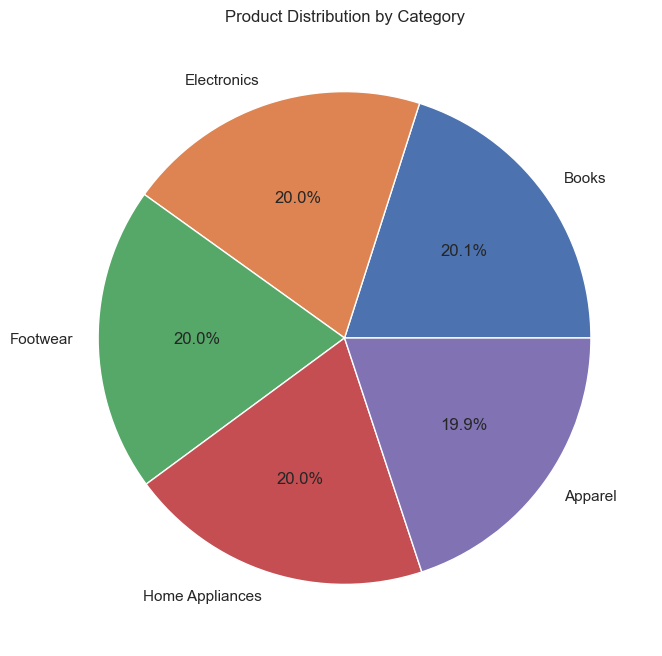

In [5]:
plt.figure(figsize=(10, 8))
df["Category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Product Distribution by Category")
plt.ylabel("")
plt.show()

### Visualization 2: Price vs. Popularity Correlation
Checking if higher priced items are more or less popular.

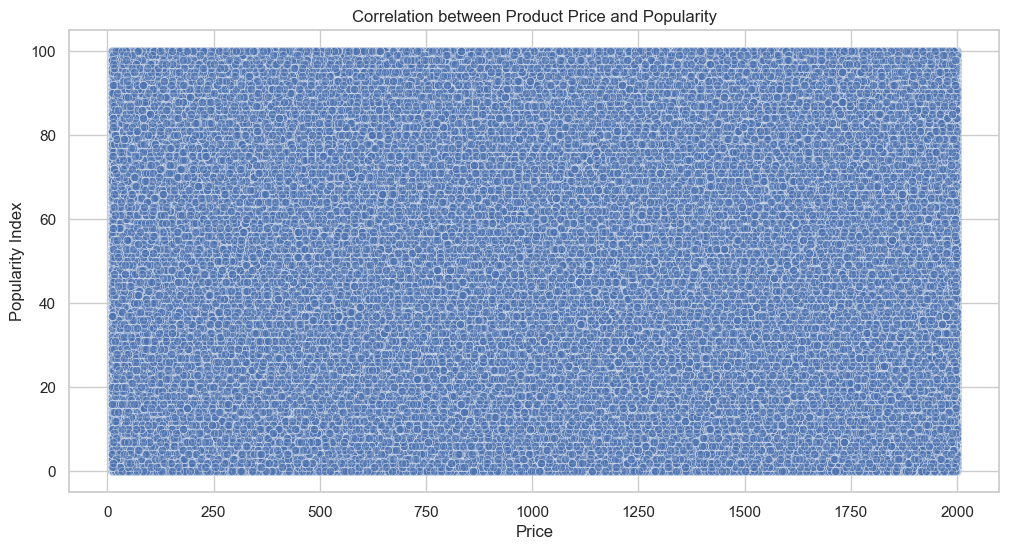

In [6]:
sns.scatterplot(data=df, x="Price", y="Popularity Index", alpha=0.5)
plt.title("Correlation between Product Price and Popularity")
plt.show()

### Visualization 3: Discount Strategy per Category
Identifying which categories receive the highest discounts.

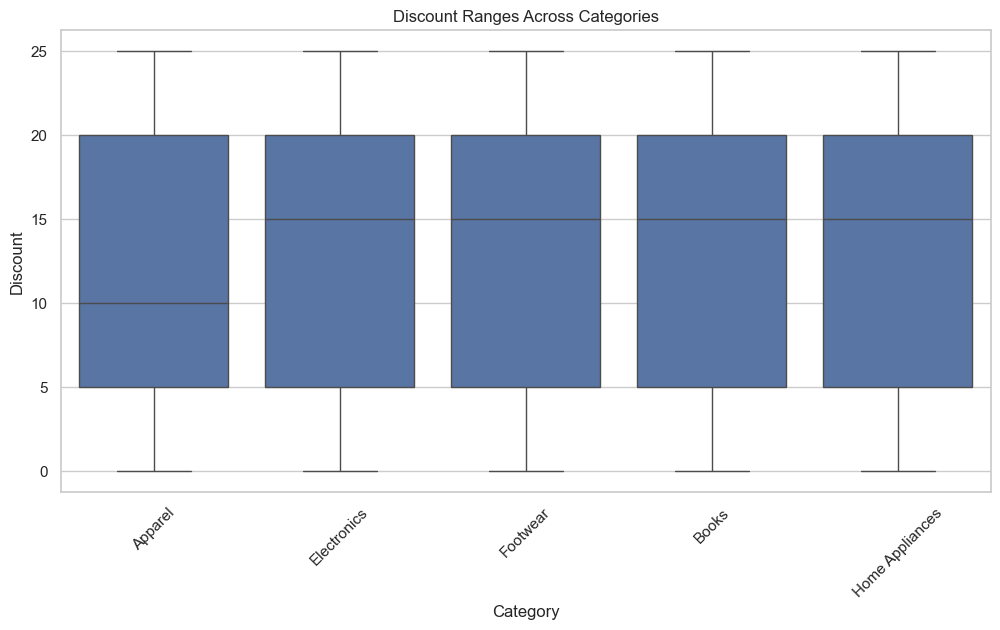

In [7]:
sns.boxplot(data=df, x="Category", y="Discount")
plt.title("Discount Ranges Across Categories")
plt.xticks(rotation=45)
plt.show()

### Visualization 4: Geographic Order Volume
Where are the most orders coming from?

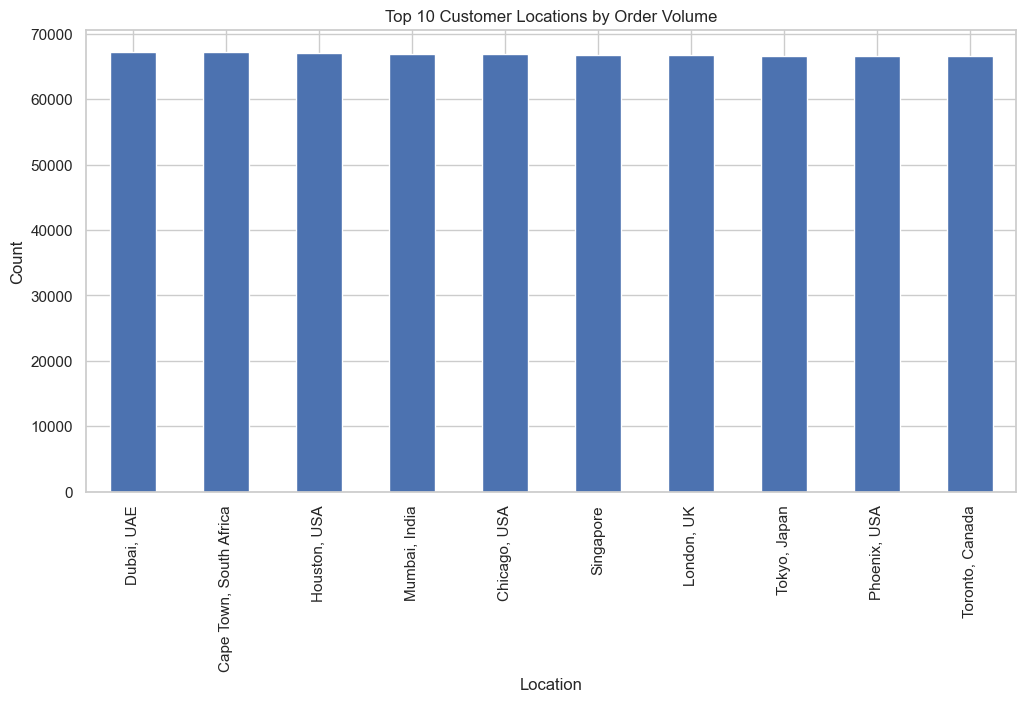

In [8]:
df["Customer Location"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer Locations by Order Volume")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

### Visualization 5: Shipping Method vs. Cost
Analyzing the cost variation across different shipping methods.

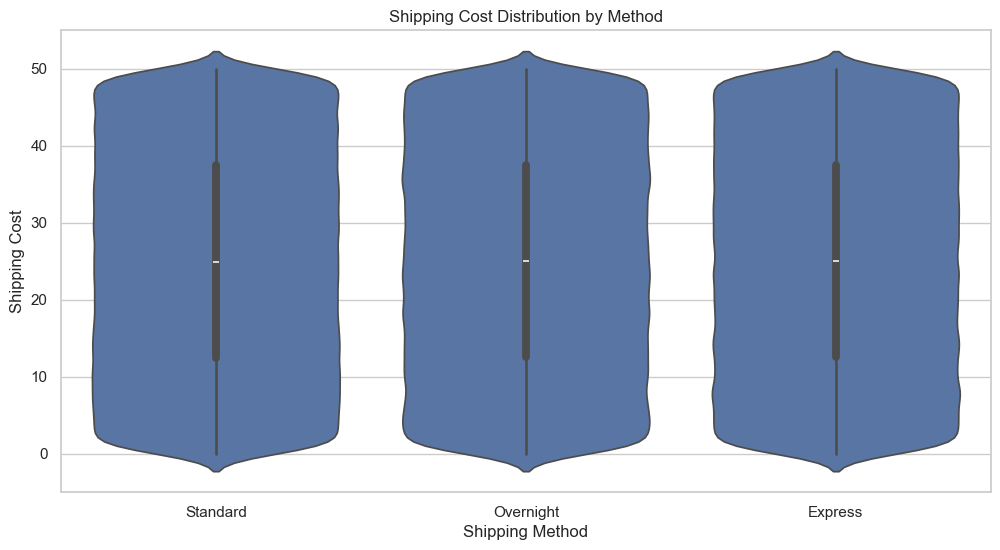

In [9]:
sns.violinplot(data=df, x="Shipping Method", y="Shipping Cost")
plt.title("Shipping Cost Distribution by Method")
plt.show()

### Visualization 6: Product Popularity by Age Group
Identifying target demographics for products.

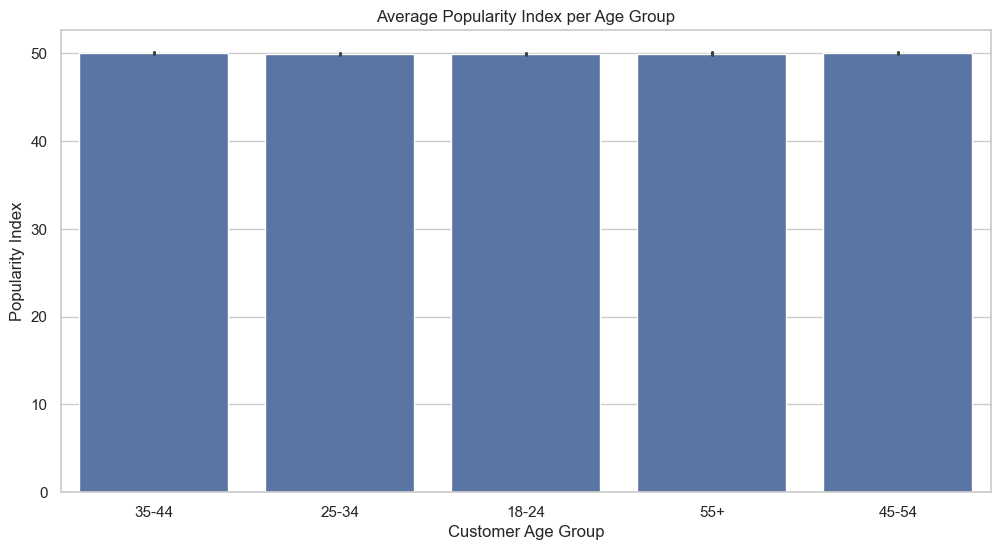

In [10]:
sns.barplot(data=df, x="Customer Age Group", y="Popularity Index", estimator=np.mean)
plt.title("Average Popularity Index per Age Group")
plt.show()

### Visualization 7: Net Price Distribution
Examining the price density after discounts and taxes.

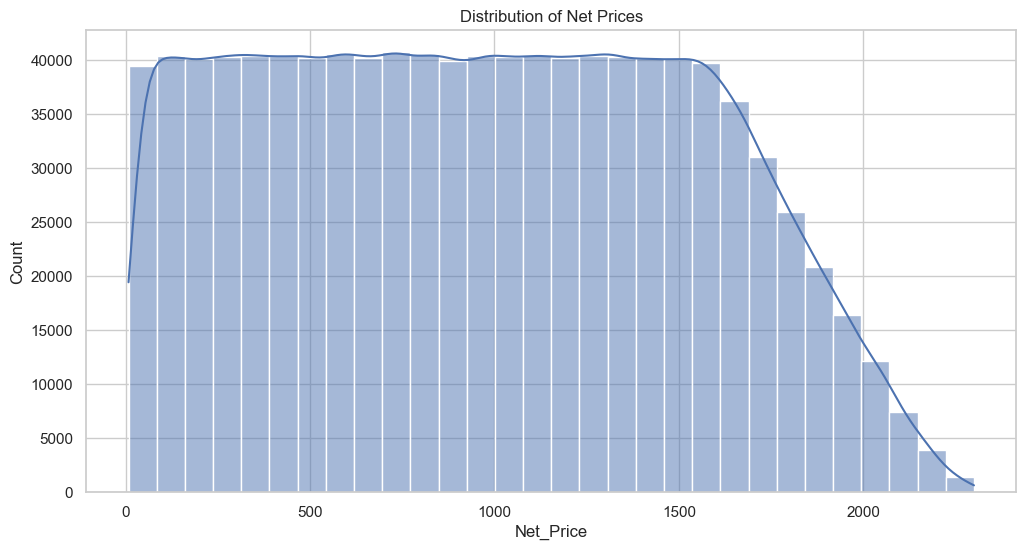

In [11]:
sns.histplot(df["Net_Price"], kde=True, bins=30)
plt.title("Distribution of Net Prices")
plt.show()

### Visualization 8: Relation between Stock Level and Return Rate
Checking if overstocking correlates with item returns.

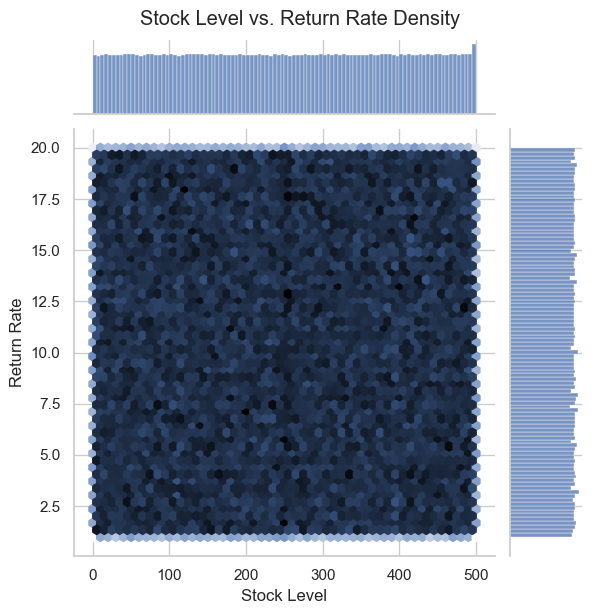

In [12]:
sns.jointplot(data=df, x="Stock Level", y="Return Rate", kind="hex")
# Use suptitle for jointplot as it returns a JointGrid object
plt.gcf().suptitle("Stock Level vs. Return Rate Density", y=1.02)
plt.show()

### Visualization 9: Seasonality Impact on Popularity
Visualizing demand fluctuations across seasons.

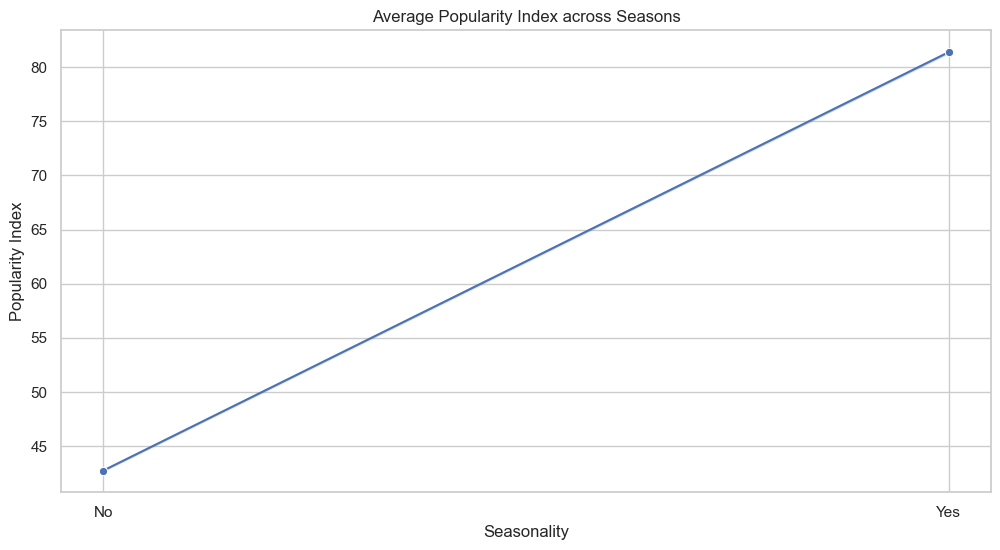

In [13]:
sns.lineplot(data=df, x="Seasonality", y="Popularity Index", estimator=np.mean, marker="o")
plt.title("Average Popularity Index across Seasons")
plt.show()

### Visualization 10: Category Preferences by Gender
Understanding buying patterns across genders.

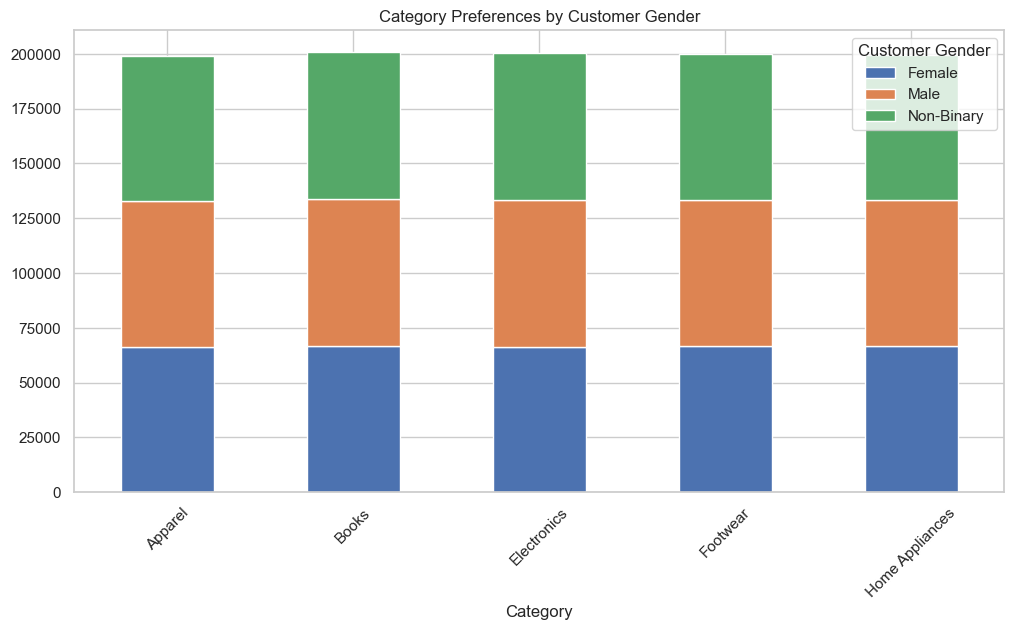

In [14]:
gender_cat = pd.crosstab(df["Category"], df["Customer Gender"])
gender_cat.plot(kind="bar", stacked=True)
plt.title("Category Preferences by Customer Gender")
plt.xticks(rotation=45)
plt.show()

### Visualization 11: Shipping Cost across Categories
Analyzing overhead costs for different product types.

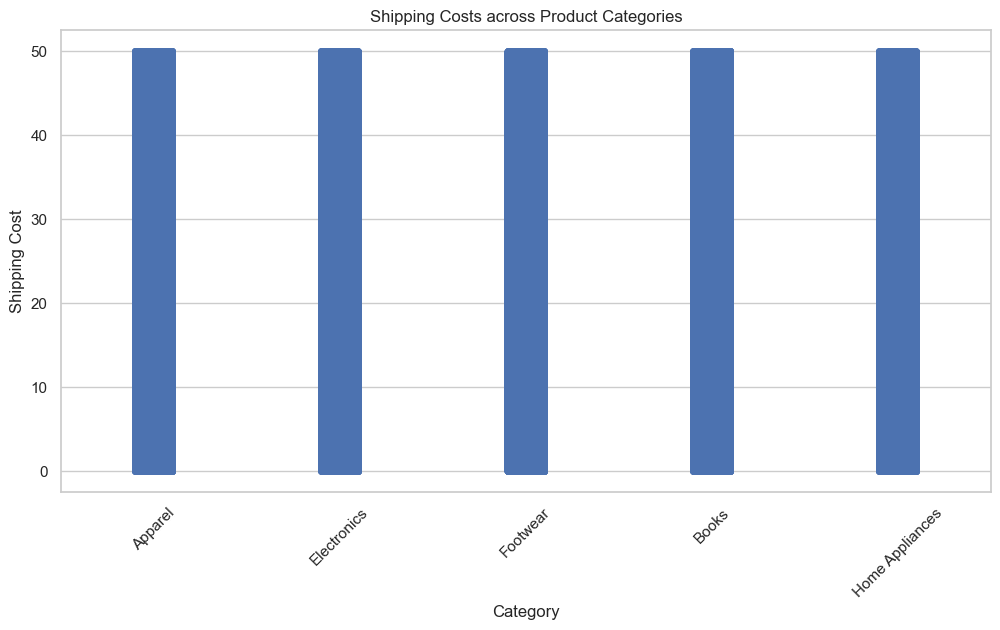

In [15]:
sns.stripplot(data=df, x="Category", y="Shipping Cost", jitter=True)
plt.title("Shipping Costs across Product Categories")
plt.xticks(rotation=45)
plt.show()

### Visualization 12: Density Estimate of Popularity
Understanding the distribution of item popularity.

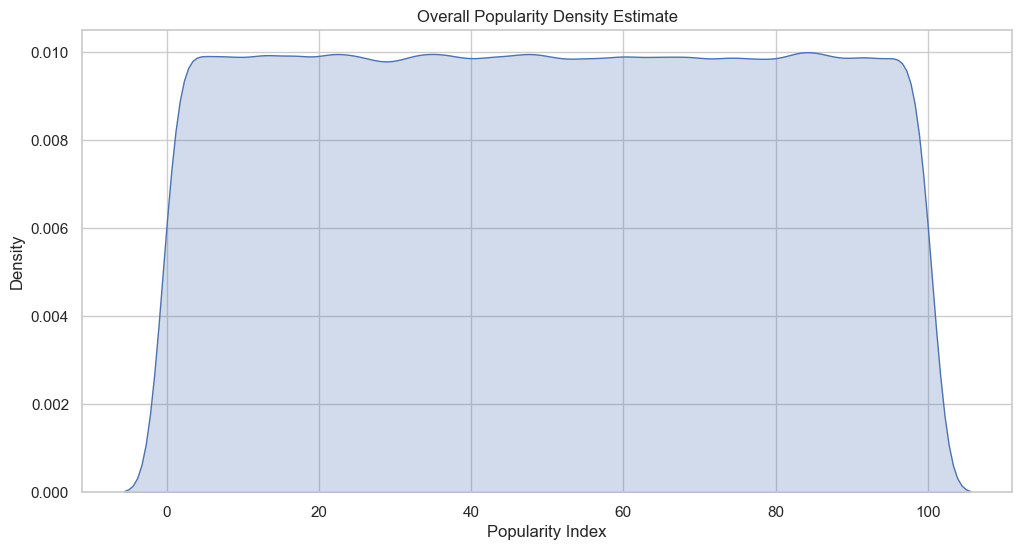

In [16]:
sns.kdeplot(data=df, x="Popularity Index", fill=True)
plt.title("Overall Popularity Density Estimate")
plt.show()

### Visualization 13: Tax Rate vs. Net Price Interaction
Analyzing how taxes influence final pricing for different categories.

KeyboardInterrupt: 

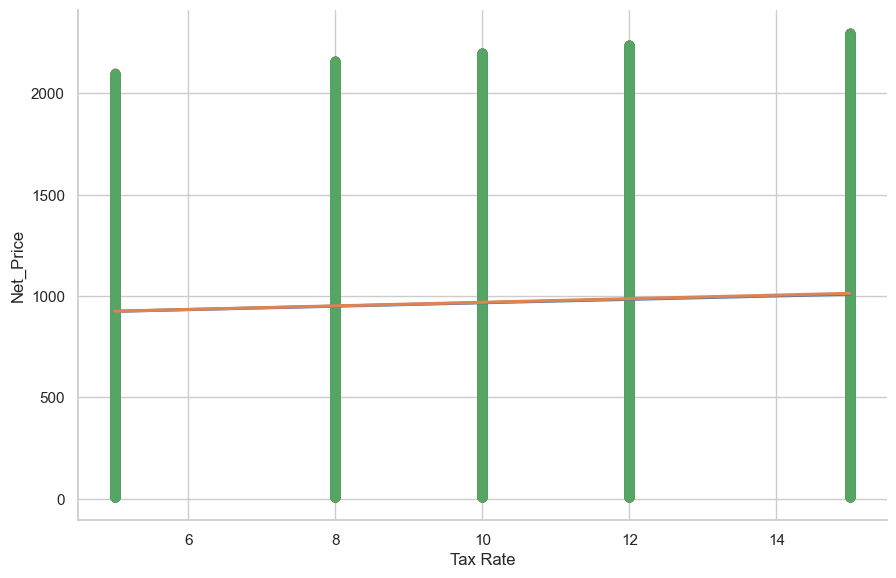

In [17]:
sns.lmplot(data=df, x="Tax Rate", y="Net_Price", hue="Category", aspect=1.5, height=6, scatter_kws={"alpha":0.3})
plt.title("Impact of Tax Rate on Net Price across Categories")
plt.show()

### Visualization 14: Quality Control by Supplier
Visualizing which suppliers have the highest return rates (Top 15).

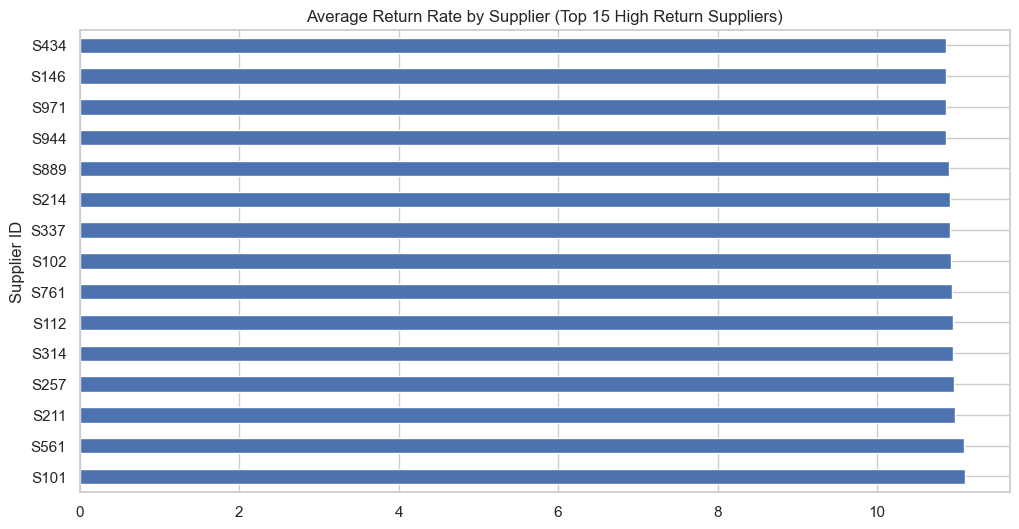

In [ ]:
supplier_returns = df.groupby("Supplier ID")["Return Rate"].mean().sort_values(ascending=False).head(15)
supplier_returns.plot(kind="barh")
plt.title("Average Return Rate by Supplier (Top 15 High Return Suppliers)")
plt.show()

### Visualization 15: Discount vs. Popularity Density
Heatmap style analysis of how discounts drive popularity.

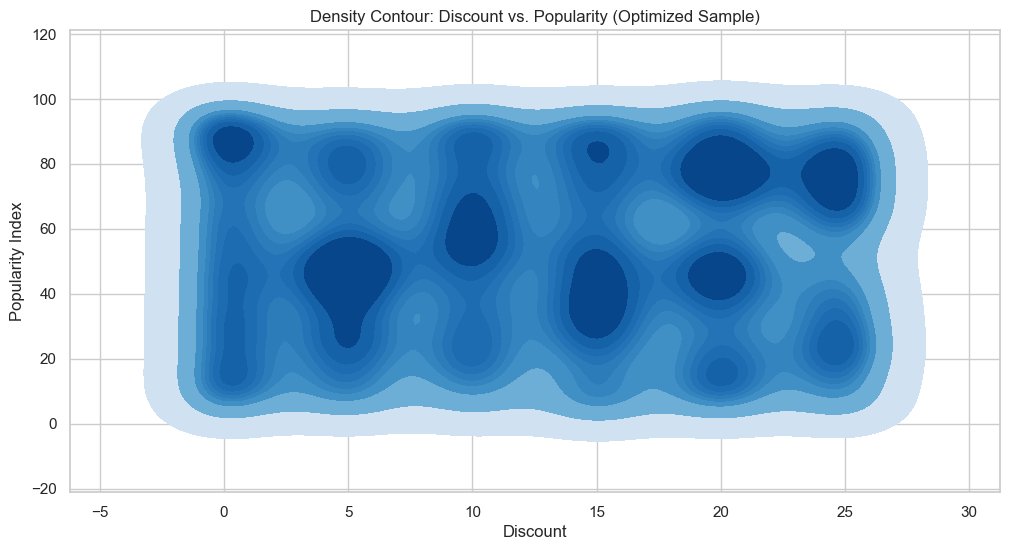

In [ ]:
# Optimization: Using a small sample (5,000) for performance on 1M rows
sns.kdeplot(data=df.sample(n=min(5000, len(df)), random_state=42), x="Discount", y="Popularity Index", fill=True, cmap="Blues")
plt.title("Density Contour: Discount vs. Popularity (Optimized Sample)")
plt.show()

### Visualization 16: Total Revenue by Day of Week
Analyzing sales performance across different days of the week.

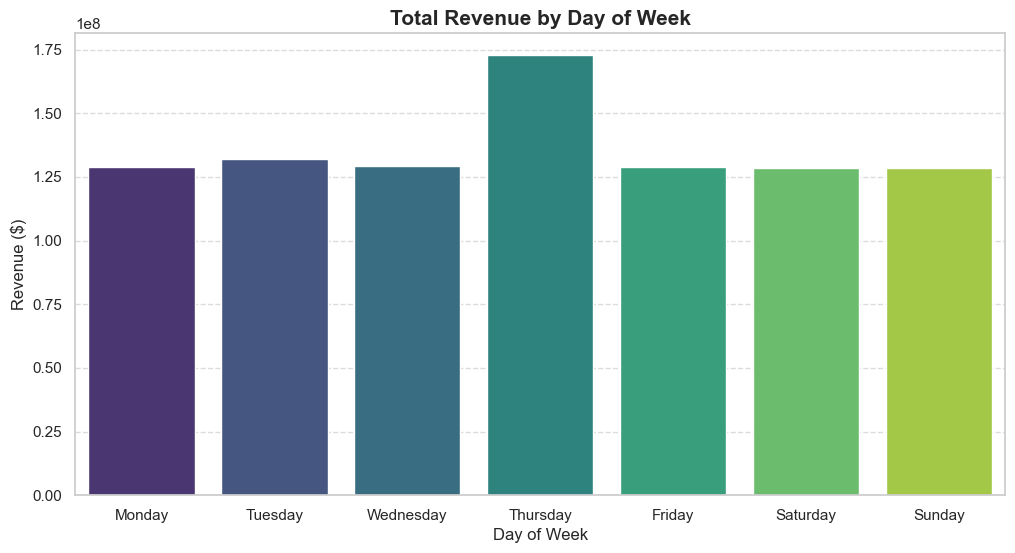

In [18]:
# Aggregating revenue by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
revenue_by_day = df.groupby('Day of Week')['Total_Order_Cost'].sum().reindex(day_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, palette="viridis", hue=revenue_by_day.index, legend=False)
plt.title("Total Revenue by Day of Week", fontsize=15, fontweight='bold')
plt.xlabel("Day of Week")
plt.ylabel("Revenue ($)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualization 17: Order Status Distribution
Percentage of completed vs. cancelled orders.

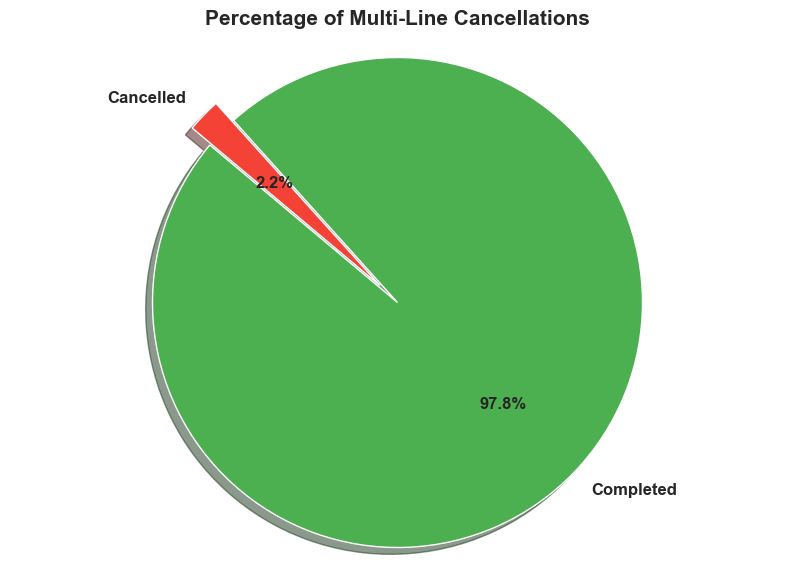

In [19]:
plt.figure(figsize=(10, 7))
status_counts = df['Order Status'].value_counts()
colors = ['#4CAF50', '#F44336'] # Green for Completed, Red for Cancelled
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=(0, 0.1), shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title("Percentage of Multi-Line Cancellations", fontsize=15, fontweight='bold')
plt.axis('equal') 
plt.show()